# scoring_model 테스트 노트북

`src/preprocessing/build_dataset.py`가 만든 `data/processed/rep_features.csv` +
`rep_sequences.npy`를 입력으로 받아, `src/scoring_model/`의 모든 함수를 하나씩
검증합니다.

테스트 항목:
1. `reference_stats.fit_reference` / `save_reference` / `load_reference` — 정상 사례 통계 학습·저장·복원
2. `scorer.mahalanobis_distance` / `distance_to_score` / `per_feature_contribution` / `score_rep`
3. `train.train_for_exercise` — CLI 진입점과 동일한 엔드투엔드 학습
4. `score_reps.score_from_features` — 이미 계산된 `rep_features.csv` 행으로 채점
5. `score_reps.score_rep_sequence` — 아직 특징이 없는 새 rep 시퀀스를 그 자리에서 채점 (실서비스 추론 경로)
6. 이상치 주입 테스트 — 일부러 비정상적인 rep을 만들어 점수가 실제로 낮게 나오는지 확인

> 실제 `data/processed/rep_features.csv`가 있으면 그걸 쓰고, 없으면
> 이 노트북 안에서 합성 특징 데이터로 대체해 테스트합니다.

## 0. 환경 설정 및 import

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 프로젝트 루트 기준 (노트북이 notebooks/ 아래에 있다고 가정)
project_root = Path(".").resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.scoring_model.reference_stats import fit_reference, save_reference, load_reference, ReferenceStats
from src.scoring_model.scorer import mahalanobis_distance, distance_to_score, per_feature_contribution, score_rep
from src.scoring_model.train import train_for_exercise, META_COLUMNS, is_feature_column
from src.scoring_model.score_reps import score_from_features, score_rep_sequence
from src.preprocessing.feature_extraction import extract_rep_features
from src.preprocessing.coordiante_normalization import normalize_landmarks
from src.preprocessing.phase_normalization import normalize_phase
from src.preprocessing.angles import EXERCISE_JOINTS

plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=3, suppress=True)

## 1. 테스트용 rep_features 로드 (실 데이터 있으면 사용, 없으면 합성 생성)

In [6]:
PROCESSED_DIR = project_root / "data" / "processed"
EXERCISE = "squat"  # 실제 데이터에 맞춰 "pushup" 등으로 바꿔도 됨
TARGET_LENGTH = 100


def make_synthetic_rep_sequence(exercise, angle_min=80, angle_max=170, seed=0, T=60, target_length=TARGET_LENGTH):
    """
    exercise의 첫 번째 관절(EXERCISE_JOINTS 기준, squat->knee, pushup->elbow)이
    angle_min~angle_max 사이로 굽혀지는 합성 rep 시퀀스를 IK 방식으로 생성.
    calculate_angle(a, b, c)의 정의(B가 꼭짓점)를 그대로 이용해, B->C 방향은
    고정하고 B->A 방향만 회전시켜 원하는 각도가 나오도록 만든다.
    """
    rng = np.random.default_rng(seed)
    t = np.linspace(0, np.pi, T)  # 양 끝은 peak(각도 최대), 중간이 valley(각도 최소)
    angle_curve = angle_max - (angle_max - angle_min) * np.sin(t)

    joint_name = next(iter(EXERCISE_JOINTS[exercise]))
    a_l, b_l, c_l = EXERCISE_JOINTS[exercise][joint_name]["left"]
    a_r, b_r, c_r = EXERCISE_JOINTS[exercise][joint_name]["right"]

    seg_len = 0.20
    keypoints = np.zeros((T, 33, 3), dtype=np.float32)
    keypoints[..., 2] = 0.95  # visibility

    b_pos_l = np.array([0.45, 0.5])  # 꼭짓점(B, 예: 무릎/팔꿈치) 위치는 고정
    b_pos_r = np.array([0.55, 0.5])
    c_dir = np.array([0.0, 1.0])  # B->C 방향(예: 무릎->발목)은 고정

    for i in range(T):
        theta_l = np.radians(angle_curve[i])
        theta_r = np.radians(angle_curve[i] + rng.normal(0, 1.0))  # 좌우 약간의 노이즈
        R_l = np.array([[np.cos(theta_l), -np.sin(theta_l)], [np.sin(theta_l), np.cos(theta_l)]])
        R_r = np.array([[np.cos(theta_r), np.sin(theta_r)], [-np.sin(theta_r), np.cos(theta_r)]])
        a_dir_l = R_l @ c_dir
        a_dir_r = R_r @ c_dir

        keypoints[i, c_l, :2] = b_pos_l + c_dir * seg_len
        keypoints[i, a_l, :2] = b_pos_l + a_dir_l * seg_len
        keypoints[i, b_l, :2] = b_pos_l

        keypoints[i, c_r, :2] = b_pos_r + c_dir * seg_len
        keypoints[i, a_r, :2] = b_pos_r + a_dir_r * seg_len
        keypoints[i, b_r, :2] = b_pos_r

    return normalize_phase(normalize_landmarks(keypoints, n_spatial_dims=2), target_length=target_length)


def make_synthetic_dataset(exercise, n_reps=60, seed=0) -> pd.DataFrame:
    """
    실제 rep_features.csv가 없을 때 대체할 합성 데이터셋.
    특징 스키마를 손으로 다시 정의하지 않고, 합성 keypoint 시퀀스를 실제
    extract_rep_features()에 그대로 통과시켜서 만든다 — 이렇게 해야 나중에
    특징 스키마가 바뀌어도(예: select_reliable_side 도입, phase-bin 추가) 이 노트북이
    낡은 스키마를 하드코딩해서 어긋나는 일이 없다.
    """
    rng = np.random.default_rng(seed)
    rows = []
    for i in range(n_reps):
        angle_min = 80 + rng.normal(0, 5)
        angle_max = 170 + rng.normal(0, 4)
        rep_seq = make_synthetic_rep_sequence(exercise, angle_min=angle_min, angle_max=angle_max, seed=i)
        feat = extract_rep_features(rep_seq, exercise)
        rows.append({"video_id": f"synthetic_{i:03d}", "exercise": exercise, "rep_idx": 0, **feat})

    df = pd.DataFrame(rows)
    df["seq_index"] = np.arange(len(df))
    return df


rep_features_path = PROCESSED_DIR / "rep_features.csv"
if rep_features_path.exists():
    rep_features_df = pd.read_csv(rep_features_path)
    if EXERCISE not in rep_features_df["exercise"].unique():
        print(f"rep_features.csv에 '{EXERCISE}' 데이터가 없어 합성 데이터로 대체합니다.")
        rep_features_df = make_synthetic_dataset(EXERCISE)
    else:
        print(f"실 데이터 로드: {rep_features_path}")
else:
    print("rep_features.csv 없음 -> 합성 데이터로 대체")
    rep_features_df = make_synthetic_dataset(EXERCISE)

subset = rep_features_df[rep_features_df["exercise"] == EXERCISE].reset_index(drop=True)
candidate_names = [c for c in subset.columns if is_feature_column(c)]

# rep_features.csv에 여러 운동이 함께 저장돼 있으면, 지금 EXERCISE가 안 쓰는 다른 운동의
# 컬럼(예: squat=*_knee)은 이 subset 안에서 전부 NaN으로 채워진다. 그대로 두면
# fit_reference의 mean/cov 계산이 NaN으로 오염되므로 제외한다 (train.py의 train_for_exercise와
# 동일한 로직 — 노트북은 그 함수를 쓰지 않고 자체적으로 로드하므로 여기도 똑같이 반영해야 한다).
all_nan_columns = [c for c in candidate_names if subset[c].isna().all()]
if all_nan_columns:
    print(f"[정보] '{EXERCISE}'에서 전부 NaN인 컬럼 {all_nan_columns}을(를) 특징에서 제외합니다.")
feature_names = [c for c in candidate_names if c not in all_nan_columns]
feature_matrix = subset[feature_names].to_numpy()

assert not np.isnan(feature_matrix).any(), (
    "특징 행렬에 NaN이 남아있습니다. rep_features.csv에 여러 운동이 섞여있지 않은지, "
    "또는 일부 행만 NaN인 결측 rep이 있는지 확인하세요."
)

print(f"'{EXERCISE}' rep {len(subset)}개, 특징 {len(feature_names)}개: {feature_names}")
subset.head()

실 데이터 로드: C:\Users\kccistc\Desktop\workspace\hometrainer\data\processed\rep_features.csv
[정보] 'squat'에서 전부 NaN인 컬럼 ['min_angle_elbow', 'max_angle_elbow', 'rom_elbow', 'elbow_bin00', 'elbow_bin01', 'elbow_bin02', 'min_angle_hip', 'max_angle_hip', 'rom_hip', 'hip_bin00', 'hip_bin01', 'hip_bin02', 'min_angle_shoulder', 'max_angle_shoulder', 'rom_shoulder', 'shoulder_bin00', 'shoulder_bin01', 'shoulder_bin02']을(를) 특징에서 제외합니다.
'squat' rep 574개, 특징 6개: ['min_angle_knee', 'max_angle_knee', 'rom_knee', 'knee_bin00', 'knee_bin01', 'knee_bin02']


,video_id,exercise,rep_idx,min_angle_elbow,max_angle_elbow,rom_elbow,elbow_bin00,elbow_bin01,elbow_bin02,reliable_side_elbow,...,knee_bin02,reliable_side_knee,min_angle_shoulder,max_angle_shoulder,rom_shoulder,shoulder_bin00,shoulder_bin01,shoulder_bin02,reliable_side_shoulder,seq_index
0,squat (1),squat,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,167.426888,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,566
1,squat (1),squat,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,167.107852,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,567
2,squat (1),squat,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,167.341482,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,568
3,squat (1),squat,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,167.731652,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,569
4,squat (1),squat,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,167.751438,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,570


## 2. `fit_reference` / `save_reference` / `load_reference` 테스트

정상 사례 특징 행렬로 평균·공분산을 학습하고, 저장했다가 다시 불러온 결과가
원본과 동일한지 확인합니다.

평균(mean): [ 97.773 178.824  81.051 166.731 120.948 167.354]
공분산 shape: (6, 6)
기준 거리 분포: min=0.294, median=1.431, max=17.705

저장/재로드 라운드트립 검증 통과.


c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 47168 (\N{HANGUL SYLLABLE RYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE 

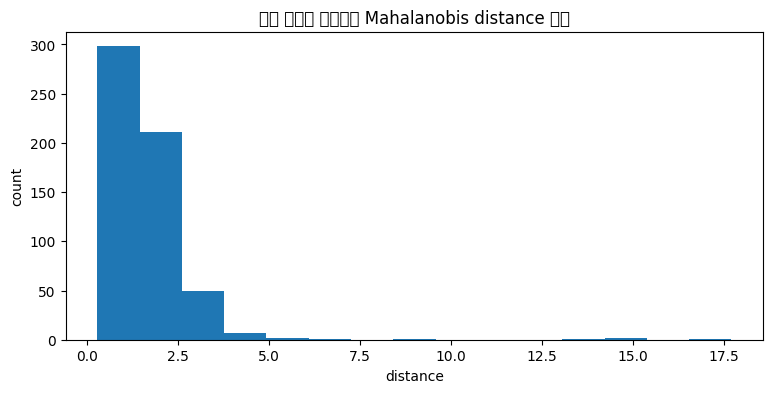

In [7]:
stats = fit_reference(feature_matrix, feature_names, exercise=EXERCISE)

print("평균(mean):", stats.mean)
print("공분산 shape:", stats.cov.shape)
print("기준 거리 분포: min=%.3f, median=%.3f, max=%.3f" % (
    stats.reference_distances.min(), np.median(stats.reference_distances), stats.reference_distances.max()
))

# 저장 -> 재로드 라운드트립 검증
MODEL_DIR = project_root / "models_test"
MODEL_DIR.mkdir(exist_ok=True)
save_path = MODEL_DIR / f"{EXERCISE}_reference.npz"
save_reference(stats, save_path)
stats_reloaded = load_reference(save_path)

assert np.allclose(stats.mean, stats_reloaded.mean), "재로드 후 mean이 달라짐!"
assert np.allclose(stats.inv_cov, stats_reloaded.inv_cov), "재로드 후 inv_cov가 달라짐!"
assert stats.feature_names == stats_reloaded.feature_names, "재로드 후 feature_names가 달라짐!"
print("\n저장/재로드 라운드트립 검증 통과.")

plt.hist(stats.reference_distances, bins=15)
plt.title("정상 사례들 스스로의 Mahalanobis distance 분포")
plt.xlabel("distance"); plt.ylabel("count"); plt.show()

## 3. `mahalanobis_distance` / `distance_to_score` / `per_feature_contribution` / `score_rep` 테스트

학습에 쓰인 정상 사례들을 그대로 다시 채점해, 점수 분포가 대체로 중간(50점 근방)에
몰리는지 확인합니다 (자기 자신의 분포로 채점하는 것이므로 극단적으로 낮은 점수는
드물어야 정상).

점수 분포: min=3.1, median=100.0, max=100.0


c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kccistc\.conda\envs\torch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM

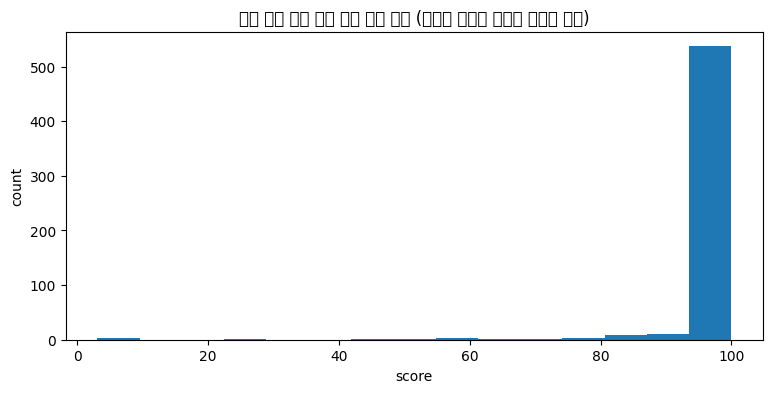


샘플 결과 구조: ['score', 'distance', 'feature_contributions', 'top_issues', 'outliers', 'outlier_messages']
상위 이슈: [('knee_bin00', -9.619884115224528), ('max_angle_knee', -1.827745803972344)]


In [8]:
scores = []
for i in range(len(feature_matrix)):
    result = score_rep(feature_matrix[i], stats)
    scores.append(result["score"])

scores = np.array(scores)
print(f"점수 분포: min={scores.min():.1f}, median={np.median(scores):.1f}, max={scores.max():.1f}")

plt.hist(scores, bins=15)
plt.title("정상 사례 자기 자신 채점 결과 분포 (대체로 중간값 근처에 몰려야 정상)")
plt.xlabel("score"); plt.ylabel("count"); plt.show()

# 개별 결과 구조 확인
sample_result = score_rep(feature_matrix[0], stats)
print("\n샘플 결과 구조:", list(sample_result.keys()))
print("상위 이슈:", sample_result["top_issues"])

## 4. `train_for_exercise` 테스트 (CLI 진입점과 동일한 엔드투엔드 경로)

`data/processed/rep_features.csv`가 실제로 있을 때만 의미 있는 테스트입니다
(합성 데이터로 대체된 경우 임시 파일로 만들어 검증).

In [9]:
TEST_PROCESSED_DIR = project_root / "data_test_processed"
TEST_PROCESSED_DIR.mkdir(exist_ok=True)
subset.to_csv(TEST_PROCESSED_DIR / "rep_features.csv", index=False)

TEST_MODEL_DIR = project_root / "models_test"
train_for_exercise(TEST_PROCESSED_DIR, EXERCISE, TEST_MODEL_DIR)

trained_stats = load_reference(TEST_MODEL_DIR / f"{EXERCISE}_reference.npz")
assert trained_stats.feature_names == feature_names
print("\ntrain_for_exercise 정상 동작 확인 완료.")

[정보] 'squat'에서 전부 NaN인 컬럼 ['min_angle_elbow', 'max_angle_elbow', 'rom_elbow', 'elbow_bin00', 'elbow_bin01', 'elbow_bin02', 'min_angle_hip', 'max_angle_hip', 'rom_hip', 'hip_bin00', 'hip_bin01', 'hip_bin02', 'min_angle_shoulder', 'max_angle_shoulder', 'rom_shoulder', 'shoulder_bin00', 'shoulder_bin01', 'shoulder_bin02']을(를) 특징에서 제외합니다 (다른 운동 전용 컬럼이 rep_features.csv에 함께 저장돼 있는 경우 정상입니다).
'squat' rep 574개로 학습 시작, 특징 벡터 shape: (574, 6)
특징: ['min_angle_knee', 'max_angle_knee', 'rom_knee', 'knee_bin00', 'knee_bin01', 'knee_bin02']
기준 거리 분포 (percentile 스코어 보정용): min=0.294, median=1.708, max=17.705
저장 완료: C:\Users\kccistc\Desktop\workspace\hometrainer\models_test\squat_reference.npz

train_for_exercise 정상 동작 확인 완료.


## 5. `score_from_features` 테스트

`rep_features.csv`에 이미 계산된 행을 재계산 없이 바로 채점하는 경로입니다
(실제 서비스에서 학습 데이터를 다시 채점해볼 때 쓰는 빠른 경로).

In [ ]:
for i in range(min(3, len(subset))):
    row = subset.iloc[i]
    result = score_from_features(row, stats)
    print(f"rep_idx={row['rep_idx']} video_id={row['video_id']} "
          f"-> score={result['score']:.1f} (distance={result['distance']:.3f})")
    print(f"   상위 이슈: {result['top_issues']}")

## 6. `score_rep_sequence` 테스트 (신규 영상 추론 경로)

아직 `rep_features.csv`에 없는 새 rep 시퀀스(정규화·위상정규화까지 끝난 keypoint
배열)를 그 자리에서 특징 추출 + 채점합니다. `preprocessing.feature_extraction`과의
연동까지 함께 검증합니다.

In [ ]:
# make_synthetic_rep_sequence는 1번 셀에서 이미 정의했고, 정규화·위상정규화까지 끝낸
# 시퀀스를 바로 반환하므로 여기서 다시 normalize_landmarks/normalize_phase를 안 거쳐도 된다.
new_rep_sequence = make_synthetic_rep_sequence(EXERCISE, seed=12345)

result = score_rep_sequence(new_rep_sequence, EXERCISE, TEST_MODEL_DIR)
print("새 rep 시퀀스 채점 결과:")
print(f"  score={result['score']:.1f}, distance={result['distance']:.3f}")
print(f"  상위 이슈: {result['top_issues']}")

## 7. 이상치 주입 테스트

일부러 가동범위(ROM)가 아주 작은(무릎/팔꿈치를 살짝만 굽히는) rep을 만들어서
점수가 실제로 낮게 나오는지, `top_issues`가 그 원인을 정확히 짚어내는지 확인합니다.

In [ ]:
# 케이스 1: 가동범위가 거의 없는 (무릎/팔꿈치를 살짝만 굽히는) rep
shallow_rep = make_synthetic_rep_sequence(EXERCISE, angle_min=150, angle_max=170, seed=999)
shallow_result = score_rep_sequence(shallow_rep, EXERCISE, TEST_MODEL_DIR)
print("[가동범위 부족 케이스]")
print(f"  score={shallow_result['score']:.1f} (정상 사례 대비 낮아야 정상)")
print(f"  상위 이슈: {shallow_result['top_issues']}")

# 케이스 2: 정상 범위의 rep (비교 기준)
normal_rep = new_rep_sequence
normal_result = score_rep_sequence(normal_rep, EXERCISE, TEST_MODEL_DIR)
print("\n[정상 케이스 (비교 기준)]")
print(f"  score={normal_result['score']:.1f}")

assert shallow_result["score"] < normal_result["score"], (
    "가동범위가 부족한 rep이 정상 rep보다 점수가 높게 나왔습니다 — scorer 로직을 점검하세요."
)
print("\n✅ 이상치 rep이 정상 rep보다 낮은 점수를 받는 것을 확인했습니다.")

## 8. 정리: 임시로 만든 테스트 파일 정리

In [ ]:
import shutil

shutil.rmtree(TEST_PROCESSED_DIR, ignore_errors=True)
shutil.rmtree(MODEL_DIR, ignore_errors=True)
print("테스트용 임시 폴더 정리 완료.")